In [4]:
import os, pandas as pd

In [5]:
if os.path.basename(os.getcwd()) == 'python':
    os.chdir('..')

tickets = pd.read_csv('data/raw/tickets.csv')
teams = pd.read_csv('data/raw/teams.csv')

print(tickets.shape, teams.shape)
print(tickets.dtypes)

(13, 6) (4, 3)
ticket_id           int64
month                 str
team_id               str
channel               str
resolution_hours    int64
satisfaction        int64
dtype: object


In [6]:
tickets = tickets.drop_duplicates()
print(tickets.shape)

(12, 6)


In [7]:
df = tickets.merge(teams, on='team_id', how='left')
print(df.shape)

(12, 8)


In [8]:
assert len(df) == 12
assert df['department'].isna().sum() == 0

In [9]:
df['breach_flag'] = (df['resolution_hours'] > 24).astype(int)
print(df['breach_flag'].sum())

5


In [10]:
summary = df.groupby('department').agg(total_tickets=('ticket_id', 'count'), breached=('breach_flag', 'sum'))
summary['breach_rate'] = (summary['breached'] / summary['total_tickets'] * 100).round(2)
print(summary)

            total_tickets  breached  breach_rate
department                                      
Service                 6         2        33.33
Technical               6         3        50.00


month
Jan    24.0
Feb    24.0
Mar    23.5
Name: resolution_hours, dtype: float64


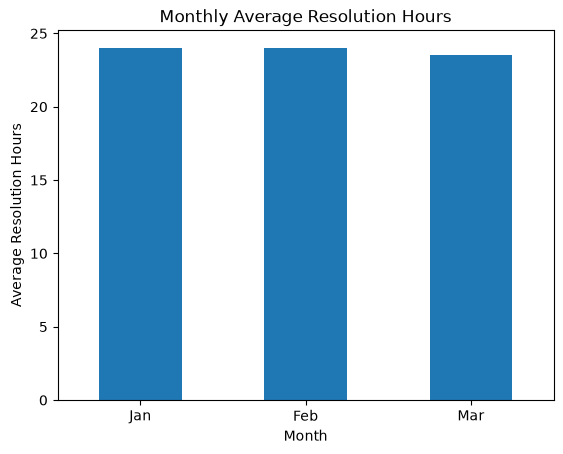

In [11]:
import matplotlib.pyplot as plt

monthly = df.groupby('month')['resolution_hours'].mean().reindex(['Jan', 'Feb', 'Mar'])
print(monthly)

monthly.plot(kind='bar', title='Monthly Average Resolution Hours', rot=0)
plt.xlabel('Month')
plt.ylabel('Average Resolution Hours')
plt.savefig('outputs/python_chart.png')
plt.show()

In [12]:
df.to_csv('outputs/clean_data.csv', index=False)
summary.to_csv('outputs/python_summary.csv')